In [13]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/twitter_dataset.csv')

# Display first few rows
print(df.head())

# Check for null values
print(df.isnull().sum())

# Basic stats
print(df.describe(include='all'))


   Tweet_ID        Username  \
0         1         julie81   
1         2   richardhester   
2         3  williamsjoseph   
3         4     danielsmary   
4         5      carlwarren   

                                                Text  Retweets  Likes  \
0  Party least receive say or single. Prevent pre...         2     25   
1  Hotel still Congress may member staff. Media d...        35     29   
2  Nice be her debate industry that year. Film wh...        51     25   
3  Laugh explain situation career occur serious. ...        37     18   
4  Involve sense former often approach government...        27     80   

             Timestamp  
0  2023-01-30 11:00:51  
1  2023-01-02 22:45:58  
2  2023-01-18 11:25:19  
3  2023-04-10 22:06:29  
4  2023-01-24 07:12:21  
Tweet_ID     0
Username     0
Text         0
Retweets     0
Likes        0
Timestamp    0
dtype: int64
           Tweet_ID  Username  \
count   10000.00000     10000   
unique          NaN      9447   
top             NaN  p

In [15]:
import re

def clean_tweet(text):
    text = str(text)
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)     # remove mentions
    text = re.sub(r'#\w+', '', text)     # remove hashtags
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    text = text.lower()                 # lowercase
    return text.strip()

df['cleaned_text'] = df['Text'].apply(clean_tweet)


In [16]:
from textblob import TextBlob

def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['cleaned_text'].apply(get_sentiment)


In [17]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Vectorizer to get top keywords
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['cleaned_text'])

# Sum frequencies of each word
word_freq = X.toarray().sum(axis=0)
words = vectorizer.get_feature_names_out()

# Create keyword frequency DataFrame
keywords_df = pd.DataFrame({'keyword': words, 'frequency': word_freq})
keywords_df = keywords_df.sort_values(by='frequency', ascending=False).head(20)

print(keywords_df)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


     keyword  frequency
288     hard        420
678      tax        412
9        add        399
391    maybe        397
295     high        397
253     food        396
758     yard        395
595   senior        394
257   forget        394
581    scene        393
666  success        393
333      job        392
383      man        392
762    young        392
198     edge        390
76       boy        390
679    teach        389
217  exactly        389
109    check        389
19     agree        389


In [19]:
print(df.columns)

Index(['Tweet_ID', 'Username', 'Text', 'Retweets', 'Likes', 'Timestamp',
       'cleaned_text', 'sentiment'],
      dtype='object')


In [20]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['date'] = df['Timestamp'].dt.date
df['hour'] = df['Timestamp'].dt.hour

# Group by date and sentiment
daily_sentiment = df.groupby(['date', 'sentiment']).size().unstack().fillna(0)
print(daily_sentiment.tail())


sentiment   Negative  Neutral  Positive
date                                   
2023-05-11      14.0      3.0      69.0
2023-05-12      16.0      1.0      68.0
2023-05-13       9.0      3.0      50.0
2023-05-14      16.0      1.0      48.0
2023-05-15       4.0      0.0      20.0


<ipython-input-21-06289fd1372b>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='pastel')


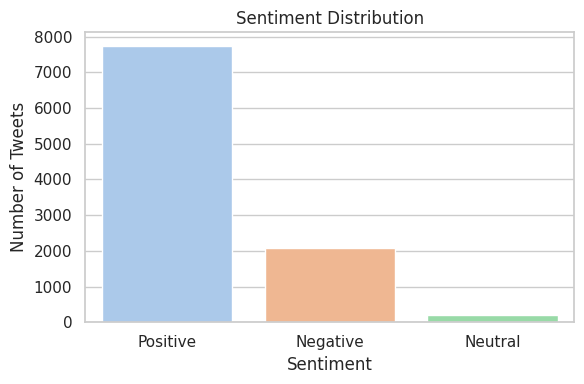

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set(style='whitegrid')

# Plot sentiment count
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment', palette='pastel')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.show()


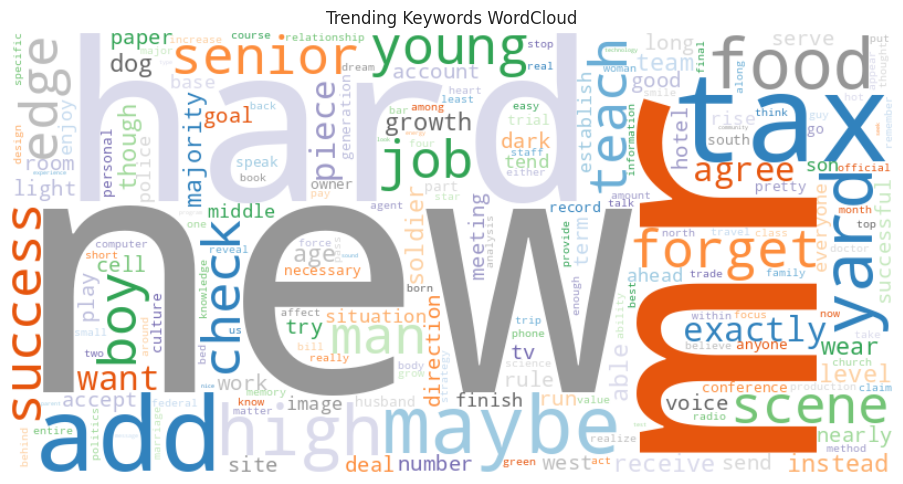

In [22]:
from wordcloud import WordCloud

# Combine all cleaned tweets
all_words = ' '.join(df['cleaned_text'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab20c').generate(all_words)

# Display the wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Trending Keywords WordCloud')
plt.tight_layout()
plt.show()


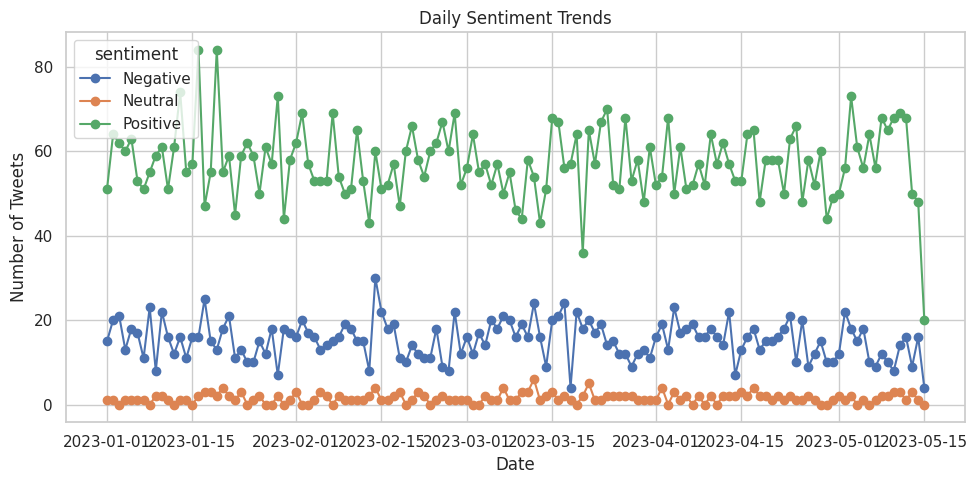

In [23]:
# Ensure 'daily_sentiment' from Step 5 is ready
daily_sentiment.plot(figsize=(10, 5), marker='o')
plt.title('Daily Sentiment Trends')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.grid(True)
plt.tight_layout()
plt.show()


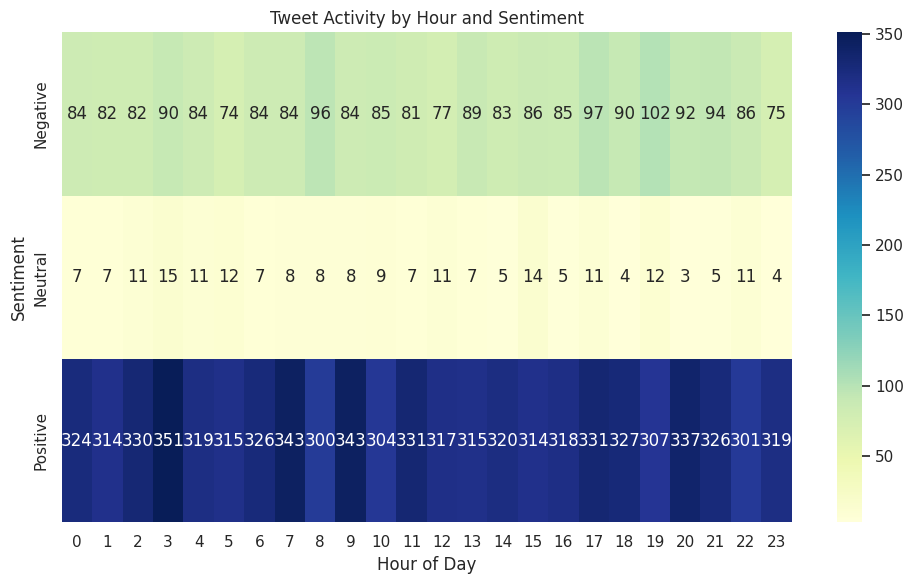

In [24]:
# Group tweets by hour and sentiment
hourly = df.groupby(['hour', 'sentiment']).size().unstack().fillna(0)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(hourly.T, cmap='YlGnBu', annot=True, fmt='g')
plt.title('Tweet Activity by Hour and Sentiment')
plt.xlabel('Hour of Day')
plt.ylabel('Sentiment')
plt.tight_layout()
plt.show()


In [26]:
!pip install dash dash-bootstrap-components pyngrok wordcloud


In [38]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import base64
from io import BytesIO
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer

from pyngrok import conf, ngrok
import dash
from dash import dcc, html, Input, Output
import dash_bootstrap_components as dbc
import plotly.express as px

# 1️⃣ Load your dataset (replace with your actual filename if different)
df = pd.read_csv("/content/drive/MyDrive/twitter_dataset.csv")  # Upload file in Colab if not already

# 2️⃣ Preprocess data
df['cleaned_text'] = df['Text'].astype(str)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Sentiment analysis using TextBlob if sentiment column is missing
if 'sentiment' not in df.columns:
    def get_sentiment(text):
        score = TextBlob(text).sentiment.polarity
        return 'Positive' if score > 0 else 'Negative' if score < 0 else 'Neutral'
    df['sentiment'] = df['cleaned_text'].apply(get_sentiment)

# Sentiment count
sentiment_count = df['sentiment'].value_counts().reset_index()
sentiment_count.columns = ['Sentiment', 'Count']

# Daily sentiment trends
df['date'] = pd.to_datetime(df['Timestamp']).dt.date
daily_sentiment = df.groupby(['date', 'sentiment']).size().unstack().fillna(0).reset_index()

# Top keywords
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['cleaned_text'])
word_freq = X.toarray().sum(axis=0)
words = vectorizer.get_feature_names_out()
keywords_df = pd.DataFrame({'Keyword': words, 'Frequency': word_freq})
top_keywords = keywords_df.sort_values(by='Frequency', ascending=False).head(10)

# Generate WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['cleaned_text']))
img = BytesIO()
plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.savefig(img, format='png')
plt.close()
img.seek(0)
encoded_image = base64.b64encode(img.read()).decode()

# 3️⃣ Authenticate ngrok (replace token with your own)
conf.get_default().auth_token = "2wMtI4nO4hfsPpwMmGhB7ArQg4q_36Wq3FMxNkjheZ6WZ75z2"
public_url = ngrok.connect(8050)
print("🔗 Your dashboard is live at:", public_url)

# 4️⃣ Build the Dash app
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

app.layout = dbc.Container([
    html.H1("📊 Twitter Trend & Sentiment Dashboard", className="text-center my-4"),

    dbc.Row([
        dbc.Col([
            html.H5("Sentiment Distribution"),
            dcc.Graph(
                figure=px.bar(sentiment_count, x='Sentiment', y='Count',
                              color='Sentiment', color_discrete_sequence=px.colors.qualitative.Pastel))
        ], width=6),

        dbc.Col([
            html.H5("Top 10 Trending Keywords"),
            dcc.Graph(
                figure=px.bar(top_keywords, x='Keyword', y='Frequency',
                              color='Keyword', color_discrete_sequence=px.colors.qualitative.Safe))
        ], width=6),
    ]),

    html.Hr(),

    html.H5("Daily Sentiment Trends"),
    dcc.Graph(
        figure=px.line(daily_sentiment, x='date', y=['Positive', 'Negative', 'Neutral'],
                       markers=True, color_discrete_sequence=['green', 'red', 'gray'])
    ),

    html.Hr(),

    html.H5("Trending Word Cloud"),
    html.Img(src='data:image/png;base64,{}'.format(encoded_image), style={'width': '100%', 'height': 'auto'}),

    html.Hr(),

    html.H5("Filter Tweets by Sentiment"),
    dcc.Dropdown(
        id='sentiment-dropdown',
        options=[{'label': s, 'value': s} for s in df['sentiment'].unique()],
        value='Positive',
        clearable=False,
        style={'width': '300px'}
    ),

    html.Div(id='tweet-output', className='mt-3')
])

# 5️⃣ Callback to filter tweets
@app.callback(
    Output('tweet-output', 'children'),
    Input('sentiment-dropdown', 'value')
)
def filter_tweets(selected_sentiment):
    filtered = df[df['sentiment'] == selected_sentiment]['cleaned_text'].head(5).tolist()
    return html.Ul([html.Li(tweet) for tweet in filtered])

# 6️⃣ Run the app
app.run(host="0.0.0.0", port=8050)


🔗 Your dashboard is live at: NgrokTunnel: "https://f7e0-34-106-226-199.ngrok-free.app" -> "http://localhost:8050"


<IPython.core.display.Javascript object>